In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [53]:
df = pd.read_csv(r'C:\Users\PRUTHVI\OneDrive\Desktop\EL Matador AI\data\ufc_clean.csv')

In [54]:
y = df['red_win']

columns_to_drop = list(df.select_dtypes(include=['object']).columns)
columns_to_drop.append('red_win')
print(columns_to_drop)
X = df.drop(columns=columns_to_drop)

['R_fighter', 'B_fighter', 'date', 'country', 'weight_class', 'gender', 'better_rank', 'finish', 'finish_details', 'finish_round_time', 'red_win']


In [55]:
print(X.shape)
print(y.shape)

(7177, 111)
(7177,)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('Training Samples:',X_train.shape[0])
print('Testing Samples',X_test.shape[0])

Training Samples: 5741
Testing Samples 1436


In [57]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
print('Model Training complete')

Model Training complete


In [58]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)
print(f'Initial baseline accuracy {accuracy: .2%}')

print('DEtailed Classification Report: ')
print(classification_report(y_test,predictions))

Initial baseline accuracy  65.74%
DEtailed Classification Report: 
              precision    recall  f1-score   support

           0       0.60      0.53      0.56       598
           1       0.69      0.75      0.72       838

    accuracy                           0.66      1436
   macro avg       0.65      0.64      0.64      1436
weighted avg       0.65      0.66      0.65      1436



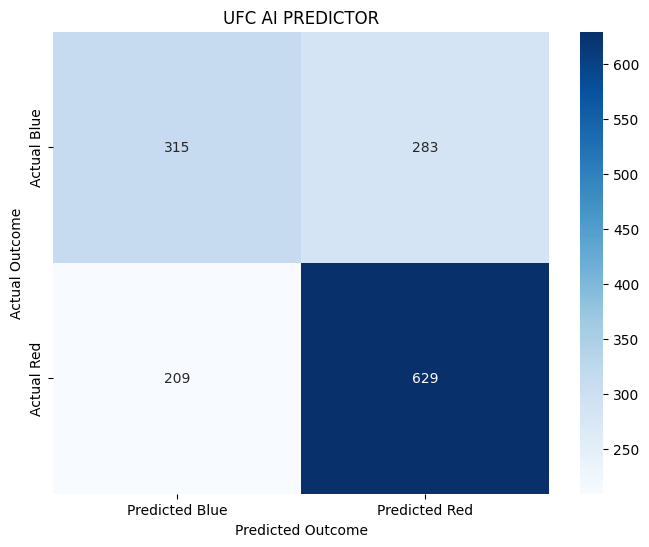

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Predicted Blue','Predicted Red'],
            yticklabels=['Actual Blue','Actual Red'])
plt.title('UFC AI PREDICTOR')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.show()


below we can see that our model is mostly dependent on the odds set by the big dawgs , so our model is not really that impressive so now we will try to create a model without the odds , just purely on the physical stats

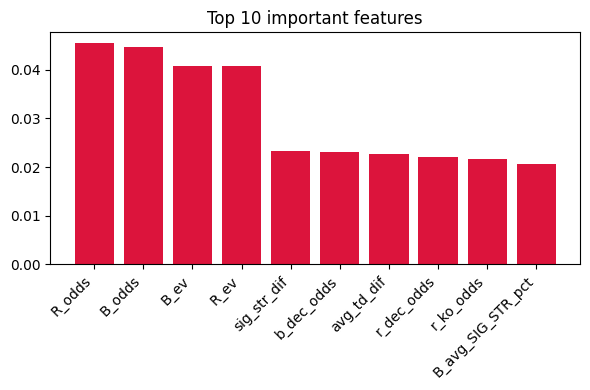

In [60]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6,4))
plt.title('Top 10 important features')
plt.bar(range(10),importances[indices[:10]],color = 'crimson',align = 'center')
plt.xticks(range(10),X.columns[indices[:10]],rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

see now even without the bets and ev we are getting a 61% accuracy thats a huge success 

In [61]:
columns_to_drop_no_odds = list(df.select_dtypes(include=['object']).columns)
columns_to_drop_no_odds.append('red_win')

odds_ev_col = [col for col in df.columns if 'odds' in col.lower() or 'ev' in col.lower() or 'profit' in col.lower()]
columns_to_drop_no_odds.extend(odds_ev_col)

X_no_odds = df.drop(columns=columns_to_drop_no_odds)

X_train_no,X_test_no,y_train_no,y_test_no = train_test_split(X_no_odds,y,test_size=0.2,random_state=42)

pure_model = RandomForestClassifier(n_estimators=100,random_state=42)
pure_model.fit(X_train_no,y_train_no)

pure_pred = pure_model.predict(X_test_no)

pure_accuracy = accuracy_score(y_test_no,pure_pred)
print('THis is the pure accuracy of the model: ',pure_accuracy*100)

THis is the pure accuracy of the model:  61.14206128133704


now that we have gotten success in high accuracy without odds we are going to reduce the dimensionality and collinearity by removing the redundant columns out of the dataset


In [62]:
diff_cols = [col for col in df.columns if 'dif' in col.lower()]

In [63]:
raw_r_cols = [col for col in df.columns if col.startswith('R_')and col not in diff_cols]
raw_b_cols = [col for col in df.columns if col.startswith('B_')and col not in diff_cols]
drop_list = raw_b_cols + raw_r_cols
drop_list.extend(list(df.select_dtypes(include=['object']).columns))
drop_list.extend([col for col in df.columns if 'odds' in col.lower() or 'ev' in col.lower() or 'profit' in col.lower()])
drop_list.append('red_win')

In [64]:
X_optimized = df.drop(columns=drop_list)
y = df['red_win']

In [65]:
X_train_opt,X_test_opt,y_train_opt,y_test_opt = train_test_split(X_optimized,y,random_state=42,test_size=0.2)

In [66]:
rf_balanced = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced',n_jobs=-1)
rf_balanced.fit(X_train_opt,y_train_opt)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [67]:
opt_predict = rf_balanced.predict(X_test_opt)

the optimize accuracy is 59.96%

In [68]:
acc = accuracy_score(y_test_opt,opt_predict)
print(f'The accuracy score is {acc:.2%}%')

The accuracy score is 59.96%%


In [69]:
cm = confusion_matrix(y_test_opt,opt_predict)
print(f'True Blue : {cm[0][0]}, False Red: {cm[0][1]}')
print(f'False Blue: {cm[1][0]},True Red: {cm[1][1]}')

True Blue : 204, False Red: 394
False Blue: 181,True Red: 657


ok now we are trying to gradient boosting using xgboost 

In [71]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [85]:
blue_wins =  (y_train_opt == 0).sum()
red_wins = (y_train_opt == 1).sum()
imbalance_ratio = blue_wins/red_wins

In [91]:
xgb_base = xgb.XGBClassifier(
    objective = 'binary:logistic',
    eval_metrics = 'logloss',
    scale_pos_weight = imbalance_ratio,
    random_state = 42,
    n_jobs = -1
)

In [92]:
parame_grid = {
    'max_depth': [3,5,7], 'learning_rate': [0.01,0.05,0.1],'n_estimators':[100,200]
}

In [93]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid= parame_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1

)

In [94]:
grid_search.fit(X_train_opt,y_train_opt)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


c:\Users\PRUTHVI\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:12:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._jobs=-1, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [96]:
best_xgb = grid_search.best_estimator_
print(grid_search.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [97]:
xgb_pred = best_xgb.predict(X_test_opt)
xgb_accuracy = accuracy_score(y_test_opt,xgb_pred)

In [98]:
print(f'The accuracy score is {xgb_accuracy:.2%}')

The accuracy score is 59.05%


In [101]:
print(classification_report(y_test_opt,xgb_pred))

              precision    recall  f1-score   support

           0       0.51      0.55      0.53       598
           1       0.66      0.62      0.64       838

    accuracy                           0.59      1436
   macro avg       0.58      0.58      0.58      1436
weighted avg       0.60      0.59      0.59      1436



In [104]:
print(confusion_matrix(y_test_opt,xgb_pred))

[[330 268]
 [320 518]]


now we have completed our model , this is the mathematical limit of it , now we are going to calculate how much roi we could generate from our model

In [106]:
final_pred = grid_search.best_estimator_.predict(X_test_opt)

In [107]:
test_indices = X_test_opt.index
roi_df = df.loc[test_indices].copy()

In [109]:
roi_df['Actual_Winner'] = y_test_opt
roi_df['AI_prediction'] = final_pred

In [116]:
def calculate_pnl(row):
    if row['AI_prediction'] == 1 and row['Actual_Winner'] == 1:
        odds = row['R_odds']
        if odds == 0:
            return 0
        if odds > 0:
            return (odds/100.0)*100.0#this 100 is the wager(so normally in this formula it is multiplied by the wager)
        else:
            return(100.0/abs(odds))*100.0
        
    elif row['AI_prediction'] == 0 and row['Actual_Winner'] == 0:
        odds = row['B_odds']
        if odds == 0:
            return 0
        if odds > 0:
            return (odds/100.0)*100.0
        else:
            return (100.0/abs(odds))*100.0
    
    else:
        return -100.0
    

In [117]:
roi_df['PnL'] = roi_df.apply(calculate_pnl,axis=1)

In [119]:
total_bets = len(roi_df)
total_profits = roi_df['PnL'].sum()
total_wagered = total_bets*100.0
roi_percentage = (total_profits/total_wagered)*100

In [125]:
print('The total amount of bets taken were:',total_bets)
print(f'The total amount wagered was {total_wagered} and the total profit was {total_profits}')
print(f'This is the Return of investment {roi_percentage:.2%}')

The total amount of bets taken were: 1436
The total amount wagered was 143600.0 and the total profit was -1245.8263295419847
This is the Return of investment -86.76%
